# High-Density High-Order Kuramoto Oscillator Network for Sequential Associative memory

We consider a smooth-evolution case where sequence members are mutations from original pattern.

## Questions:


1) For given N, what is maximum sequence length L for stable retriavial

2) For given N, how many sequences of length L can be retrieved

3) Investigate a crossing sequence for associative memory between 2 sequences

4) Does last index in markov-chain update rule reference itself or cycle through

5) Hidden Variables, implemented as additional neurons outside the pattern image (possibly)





## Model (Update Rule and OverLap):

This notebook tests d=3 high-order Kuramoto-type oscillator network 

$$\dot{\theta}_i
=
-\sin\theta_i
\sum_{\mu=1}^{P}
\xi_i^{\mu+1}
\left(
\frac{1}{N-1}
\sum_{j\neq i}
\xi_j^\mu
\cos\theta_j
\right)^d$$

Synchronise into binary because of high order d (want the phases to converge to binary in the end)

The sequence is a single chain of period $P$ with a terminal self-loop, $\xi^{P+1}
\equiv \xi^{P}$ (the last pattern points to itself rather than wrapping back to $\xi^1$),
so once the dynamics reach the last pattern they settle there instead of cycling
indefinitely.



For memory $\mu$, define the **overlap** of state with some pattern as

$$m_i^\mu(\boldsymbol{\theta})
=
\frac{1}{N-1}
\sum_{j\neq i}
\xi_j^\mu
\cos\theta_j$$

Zero overlap means half the spins are opposite; overlap 1 means total allignment; **Overlap is the order parameter = macroscopic; some information is lost**




## Implementation:

- For a given pattern, we mutate it in accordance with some rand seed to make up a sequence.

- Gradient descent is achieved via either ODE EULER or SDE (Stochastic) Euler-Maruyama time evol.

- The sequence is tracked with an online sequence tracker for overlap with stored patterns during gradient descent; tolerance set to 80 percent AND we arg max is required; strict order, meaning break traverse if encountering incorrect pattern / element

- Trials run for 20 seeds, 20 times per seed

- Classes and methods implemented in **kuramoto_library.py**

- Here we will retain self-referencing for last pattern

- Success calculated as $L_{max}(N)$: averaged out over 20 generation seeds

In [37]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np

from numba import njit, prange

import kuramoto_library as krm

import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
CONFIG = dict(
    dt=0.02,  # integration timestep for the dynamical evolution
    T=55.0,  # total simulation time
    frequency_std=0.03,  # heterogeneity in intrinsic frequencies, adding disorder to retrieval dynamics
    phase_noise=0.01,  # stochastic phase perturbations during evolution (SDE mode only)
    d=3,  # order (polynomial degree) of the high-order Kuramoto / dense associative memory coupling
    corruption_rate=0.2,  # fraction of neurons flipped in the cue used to initialize theta
    tolerance = 0.4,  # threshold for determining whether a pattern is successfully retrieved based on overlap peak
    mode="ode",  # 'ode' (deterministic Forward Euler) or 'sde' (Euler-Maruyama with phase noise)
)

# N (network size) and seed are independent variables we sweep across trials, not fixed
# run parameters, so they're kept out of CONFIG and passed to KuramotoNetwork explicitly.

# 1. Single Sequence retrieval

## 1.1 Generating a sequence by mutation

Instead of drawing $P$ independent random patterns, we generate one base pattern $A$ and
build the sequence by repeatedly mutating it: $\xi^{k+1}$ is obtained from $\xi^{k}$ by
corrupting it at `CONFIG["corruption_rate"]` -- the same flip-a-random-subset-of-spins
operation already used to build a cue, just applied to grow the sequence instead of a
one-off retrieval test. So each element is correlated with its predecessor, and the
Hamming distance from $A$ grows (roughly) with $k$ -- this is the "smooth-evolution"
sequence described above, as opposed to a chain of unrelated codes.

In [39]:
N = 40
seq_len = 8      # sequence length (excluding the base pattern because we descend into sequence)
seed = 10        # single-trial demo seed

net = krm.KuramotoNetwork(N=N, seed=seed, **CONFIG)

net.generate_patterns(["A"])
sequence_names = net.library.generate_sequence(
    base_name="A",
    seq_len=seq_len,
    corruption_rate=CONFIG["corruption_rate"],
    seed=seed,
)
sequence_names

['A', 'A_1', 'A_2', 'A_3', 'A_4', 'A_5', 'A_6', 'A_7', 'A_8']

In [40]:
seq_idx = net.library.sequence
xi_seq = net.library.xi[seq_idx]

hamming_from_base = ((xi_seq[1:] != xi_seq[0]).sum(axis=1))
hamming_consecutive = ((xi_seq[1:] != xi_seq[:-1]).sum(axis=1))

print("Sequence:", sequence_names)
print("Hamming distance from base A:      ", hamming_from_base)
print("Hamming distance consecutive steps:", hamming_consecutive)

Sequence: ['A', 'A_1', 'A_2', 'A_3', 'A_4', 'A_5', 'A_6', 'A_7', 'A_8']
Hamming distance from base A:       [ 8 14 16 16 14 18 20 16]
Hamming distance consecutive steps: [8 8 8 8 8 8 8 8]


## 1.2 Different sequences for different random seeds

The seed controls both the base pattern $A$ (drawn by the `PatternLibrary`) and the
mutation draws at each step, so different seeds give genuinely different sequences, not
just different corruption noise on top of the same one. Build one network per seed,
simulate, and plot the pattern overlaps for each.

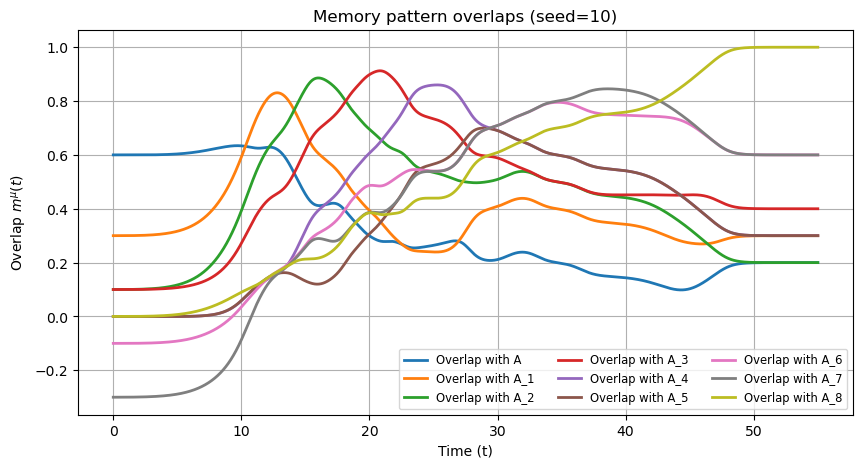

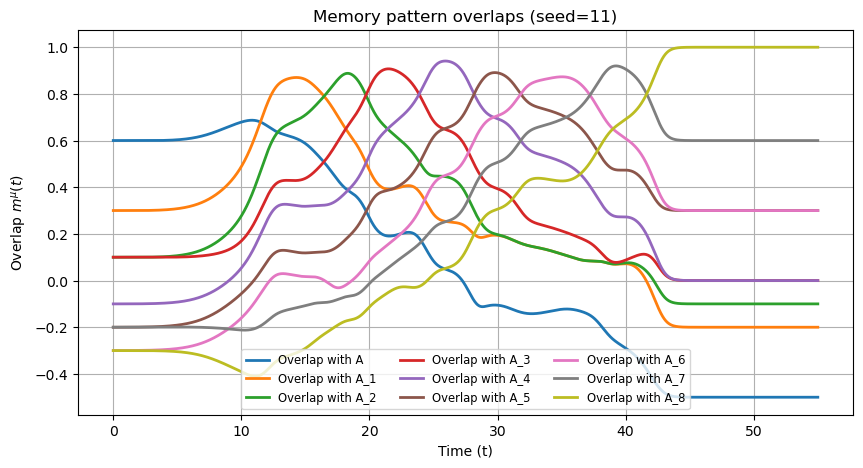

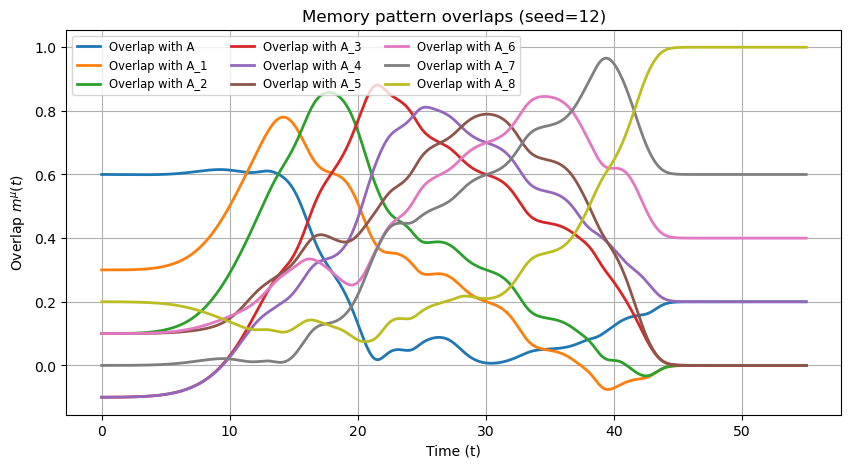

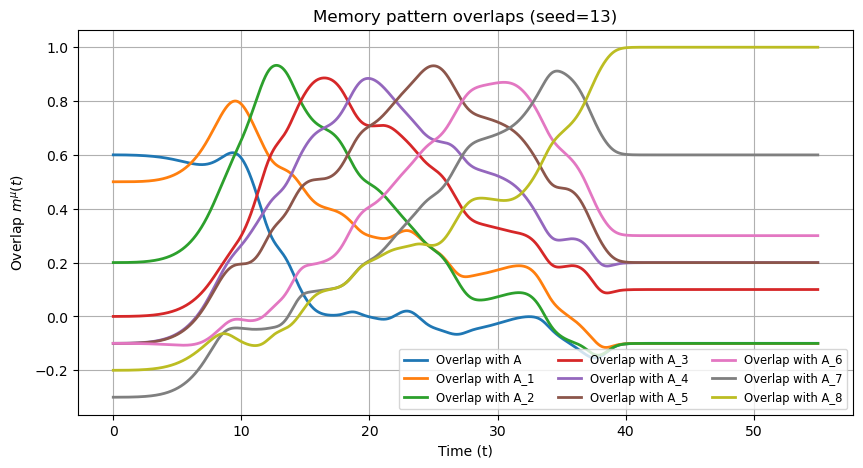

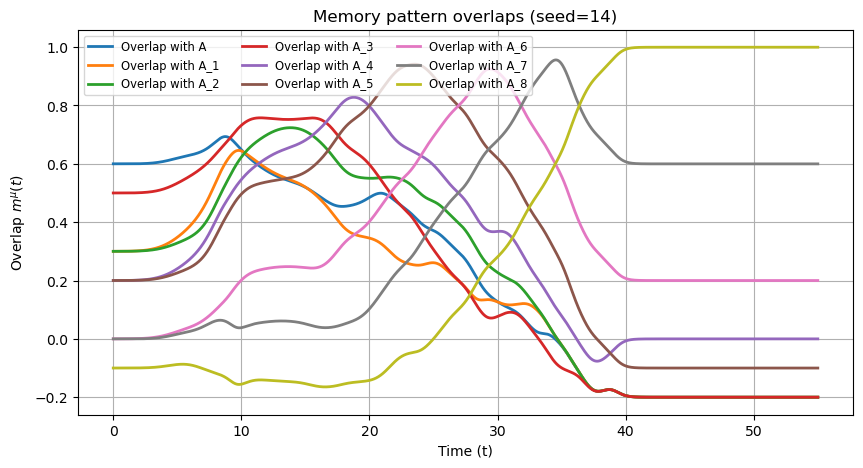

In [41]:
SEEDS = [10, 11, 12, 13, 14]

for seed in SEEDS:
    seed_net = krm.KuramotoNetwork(N=N, seed=seed, **CONFIG)
    seed_net.generate_patterns(["A"])
    seed_net.library.generate_sequence(
        base_name="A",
        seq_len=seq_len,
        corruption_rate=CONFIG["corruption_rate"],
        seed=seed,
    )
    result = seed_net.simulate(cue_pattern="A")
    seed_net.plot(result, title=f"Memory pattern overlaps (seed={seed})")

## 1.3 $L_{max}$(N): for given N, what is maximum stable L?

Employ scipy.find_peaks()

In [42]:
def run_loop(N, tolerance):

    lmax=0

    # Per-transition time budget calibrated from the single-trial demo in 1.1
    # (T=CONFIG["T"] over a length-`seq_len` chain), scaled to trial_seq_len. Without
    # this, T stays fixed regardless of chain length, so a longer trial_seq_len shrinks
    # the time available per pattern-to-pattern transition and makes retrieval harder
    # independent of N -- trial_seq_len would stop being just a measurement ceiling.
    trial_T = (CONFIG["T"] / seq_len) * trial_seq_len

    for seed in range(20):
        
        net = krm.KuramotoNetwork(N=N, seed=seed, **CONFIG)
        net.generate_patterns(["A"])
        net.library.generate_sequence(
            base_name="A",
            seq_len=trial_seq_len,
            corruption_rate=CONFIG["corruption_rate"],
            seed=seed,
        )
        result = net.simulate(cue_pattern="A", T=trial_T)
        retrieved = net.decode_sequence_peaks(result, tolerance=tolerance)
        fail_step = net.compare_to_stored_sequence(retrieved)
        lmax+=fail_step
    
    return lmax/20

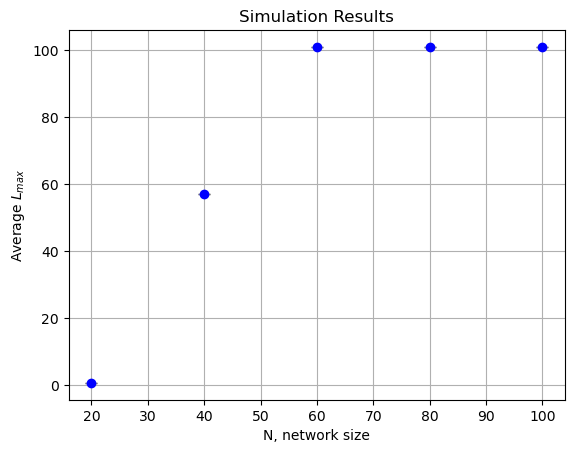

In [43]:
# could optimise the computation by parallelisation

trial_seq_len = 100

data_points = []
upper_tolerance = []
lower_tolerance = []
for N in [20, 40, 60, 80, 100]:
    avg_lmax = run_loop(N, tolerance=CONFIG["tolerance"])
    data_points.append((N, avg_lmax))

    upper_tolerance.append((N, run_loop(N, tolerance=CONFIG["tolerance"] + 0.1)))
    lower_tolerance.append((N, run_loop(N, tolerance=CONFIG["tolerance"] - 0.1)))


Ns, centers = zip(*data_points)
_, uppers = zip(*upper_tolerance)
_, lowers = zip(*lower_tolerance)

centers = np.array(centers)
uppers = np.array(uppers)
lowers = np.array(lowers)


err_low = np.clip(centers - uppers, 0, None)
err_high = np.clip(lowers - centers, 0, None)

plt.errorbar(
    Ns, centers, yerr=[err_low, err_high],
    marker='o', color='blue', ecolor='gray', capsize=4, linestyle='none',
)

# Add basic labels
plt.title("Simulation Results")
plt.xlabel("N, network size")
plt.ylabel(r"Average $L_{max}$")
plt.grid(True)

# Show the graph
plt.show()
